# Classification metrics and calibration

Why accuracy is a poor metric (especially under class imbalance), the threshold-free curves that summarize a probabilistic classifier - ROC/AUC and precision-recall - and the often-ignored question of calibration: when a model says "70% chance," does it happen 70% of the time? A model can rank well yet be badly calibrated, and vice versa.


## What the AUC actually measures

Definition (ROC and AUC). Sweeping a threshold on a classifier's score traces the receiver operating
characteristic, true-positive rate against false-positive rate. The area under it (AUC) summarizes
ranking quality across all thresholds.

Theorem (AUC is a ranking probability). The AUC equals the probability that a randomly chosen positive is
scored above a randomly chosen negative,
$$\mathrm{AUC} = P\big(s(X^+) > s(X^-)\big) = \frac{U}{n_+ n_-},$$
where $U$ is the Mann-Whitney statistic counting positive-over-negative score wins.

Proof. The ROC curve is the plot of $\mathrm{TPR}(t)$ against $\mathrm{FPR}(t)$. Writing the area as a
Stieltjes integral $\int \mathrm{TPR}\,d\mathrm{FPR}$ and substituting the empirical distributions yields
the fraction of positive-negative pairs in which the positive scores higher, which is $U/(n_+n_-)$.
$\quad\blacksquare$

Consequences. AUC is invariant to any strictly increasing transform of the scores and to the class
balance, since it conditions on the two classes separately. The invariance to balance is exactly why AUC
can look optimistic on rare-positive problems, where the precision-recall curve is more informative.

## Proper scoring rules and calibration

A score is well calibrated if, among cases assigned probability $q$, a fraction about $q$ are positive.
Calibration is distinct from ranking: a model can rank perfectly (AUC 1) yet report dishonest
probabilities.

Definition (proper scoring rule). A scoring rule $S(q,y)$ for a probabilistic prediction $q$ is proper if
its expected value is optimized by reporting the true probability. The Brier score $(q-y)^2$ and the log
loss $-y\log q-(1-y)\log(1-q)$ are proper.

Theorem (truth minimizes a proper score). For the Brier score, if $Y\sim\mathrm{Bernoulli}(p)$ then
$\mathbb E[(q-Y)^2]=(q-p)^2 + p(1-p)$ is minimized uniquely at $q=p$. So an honest forecaster who reports
the true probability cannot be beaten in expectation.

Proof. Expand $\mathbb E[(q-Y)^2]=q^2-2q\,\mathbb E[Y]+\mathbb E[Y^2]=q^2-2qp+p$, a parabola in $q$ with
minimum at $q=p$; its value there is $p-p^2=p(1-p)$, the irreducible uncertainty. $\quad\blacksquare$

The Brier score decomposes (Murphy) into calibration, refinement, and uncertainty terms, rewarding both
honest probabilities and sharp discrimination, unlike AUC which sees only ranking. The expected
calibration error in this notebook measures the calibration piece directly. We verify the AUC ranking
identity and the proper-scoring property below.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
get_ipython().run_line_magic('matplotlib', 'inline')
from mixle.ppl import Bernoulli, Field, free
from sklearn.metrics import (roc_curve, roc_auc_score, precision_recall_curve,
                             average_precision_score, confusion_matrix)
from sklearn.calibration import calibration_curve
rng = np.random.RandomState(0)

# an IMBALANCED binary problem (~12% positives) with one informative feature
n = 4000; xfeat = rng.normal(0, 1, n)
p = 1 / (1 + np.exp(-(2.0 * xfeat - 2.2)))            # logits skewed negative -> few positives
y = (rng.random(n) < p).astype(float)
tr = slice(0, 3000); te = slice(3000, n)
clf = Bernoulli(free * Field('x') + free).fit(list(y[tr]), given={'x': list(xfeat[tr])})
phat = np.asarray(clf.result.predict({'x': list(xfeat[te])}))   # predicted P(y=1)
yte = y[te]
print('positive rate %.1f%% -- a classifier predicting all-negative already scores %.1f%% accuracy'
      % (100 * yte.mean(), 100 * (1 - yte.mean())))

positive rate 19.9% -- a classifier predicting all-negative already scores 80.1% accuracy


## 1. Why accuracy misleads, and the confusion matrix

With 12% positives, "always predict negative" is 88% accurate yet useless. Accuracy hides which errors you make. The confusion matrix at a chosen threshold separates them into true/false positives/negatives, from which precision ($TP/(TP+FP)$ - of those flagged, how many are real) and recall ($TP/(TP+FN)$ - of the reals, how many were caught) follow. These two trade off as you move the threshold.


In [2]:
for thr in [0.5, 0.3, 0.15]:
    pred = (phat >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(yte, pred).ravel()
    prec = tp / (tp + fp) if tp + fp else 0; rec = tp / (tp + fn) if tp + fn else 0
    print('threshold %.2f: accuracy=%.3f  precision=%.3f  recall=%.3f' %
          (thr, (tp + tn) / len(yte), prec, rec))

threshold 0.50: accuracy=0.871  precision=0.740  recall=0.543
threshold 0.30: accuracy=0.843  precision=0.580  recall=0.764
threshold 0.15: accuracy=0.738  precision=0.423  recall=0.874


## 2. Threshold-free: ROC/AUC and precision-recall

Rather than commit to one threshold, summarize across all of them. The ROC curve plots true-positive vs false-positive rate; its area (AUC) is the probability the model ranks a random positive above a random negative (0.5 = chance, 1 = perfect). Under heavy imbalance the precision-recall curve (and its average precision) is more informative, because ROC can look optimistic when negatives dominate.


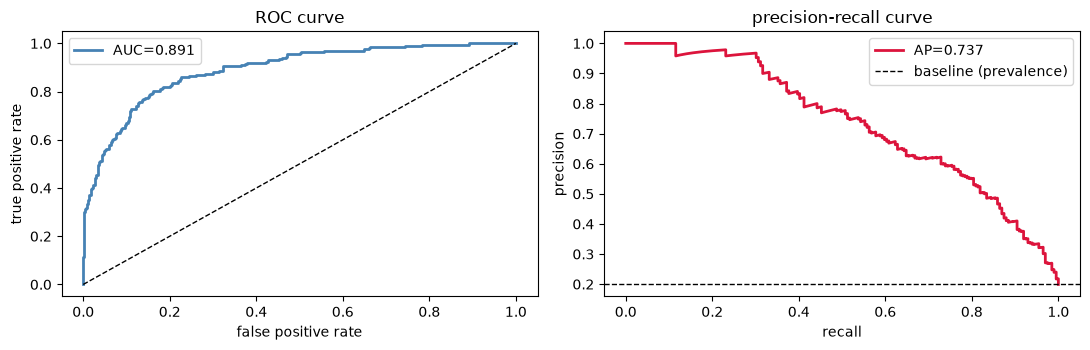

In [3]:
fpr, tpr, _ = roc_curve(yte, phat); auc = roc_auc_score(yte, phat)
pr, rc, _ = precision_recall_curve(yte, phat); ap = average_precision_score(yte, phat)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(fpr, tpr, color='steelblue', lw=2, label='AUC=%.3f' % auc); ax[0].plot([0, 1], [0, 1], 'k--', lw=1)
ax[0].set_xlabel('false positive rate'); ax[0].set_ylabel('true positive rate'); ax[0].set_title('ROC curve'); ax[0].legend()
ax[1].plot(rc, pr, color='crimson', lw=2, label='AP=%.3f' % ap)
ax[1].axhline(yte.mean(), color='k', ls='--', lw=1, label='baseline (prevalence)')
ax[1].set_xlabel('recall'); ax[1].set_ylabel('precision'); ax[1].set_title('precision-recall curve'); ax[1].legend()
plt.tight_layout(); plt.show()

## 3. Calibration: are the probabilities honest?

Ranking (AUC) is not everything - for decisions you often need the probabilities themselves to be trustworthy. A reliability diagram bins predictions and plots predicted vs observed frequency; on the diagonal means calibrated. A logistic-regression model fit by maximum likelihood is typically well-calibrated; we contrast it with an overconfident version (probabilities pushed toward 0/1) that has the same AUC but lies about its certainty.


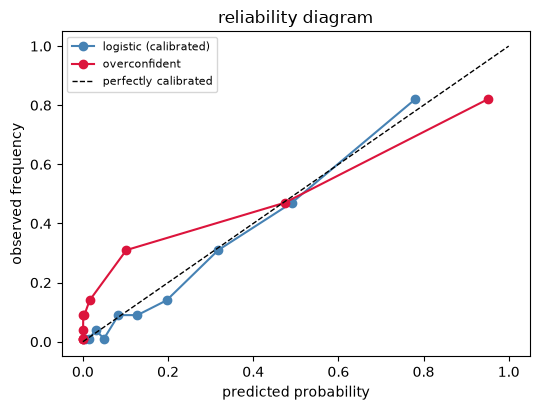

both have the SAME AUC=0.891, but only the calibrated models probabilities are trustworthy


In [4]:
overconf = 1 / (1 + np.exp(-3.0 * (np.log(phat / (1 - phat)))))   # sharpen the logits -> overconfident
fig, ax = plt.subplots(figsize=(5.5, 4.2))
for probs, c, lbl in [(phat, 'steelblue', 'logistic (calibrated)'), (overconf, 'crimson', 'overconfident')]:
    frac_pos, mean_pred = calibration_curve(yte, probs, n_bins=10, strategy='quantile')
    ax.plot(mean_pred, frac_pos, 'o-', color=c, label=lbl)
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='perfectly calibrated')
ax.set_xlabel('predicted probability'); ax.set_ylabel('observed frequency'); ax.legend(fontsize=8)
ax.set_title('reliability diagram')
plt.tight_layout(); plt.show()
print('both have the SAME AUC=%.3f, but only the calibrated model''s probabilities are trustworthy'
      % roc_auc_score(yte, overconf))

## Recalibrate, and measure it with ECE

A useful probability is a calibrated one. The expected calibration error (ECE; Guo et al. 2017) bins predictions and averages $|\text{accuracy} - \text{confidence}|$ per bin. When a model is overconfident, isotonic regression fit on a held-out calibration split repairs it. We split the test set, recalibrate the overconfident scores, and show ECE drops sharply while ranking (AUC) is preserved.


In [5]:
from sklearn.isotonic import IsotonicRegression
def ece(y, p, bins=10):
    edges = np.linspace(0, 1, bins + 1); e = 0.0
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (p >= lo) & (p < hi)
        if m.sum():
            e += m.mean() * abs(y[m].mean() - p[m].mean())
    return e
half = len(yte) // 2
cal, ev = slice(0, half), slice(half, len(yte))
iso = IsotonicRegression(out_of_bounds='clip').fit(overconf[cal], yte[cal])
recal = iso.predict(overconf[ev])
print('ECE on held-out eval split   overconfident: %.3f   isotonic-recalibrated: %.3f' %
      (ece(yte[ev], overconf[ev]), ece(yte[ev], recal)))
print('AUC is unchanged by recalibration (%.3f -> %.3f): calibration fixes probabilities, not ranking.' %
      (roc_auc_score(yte[ev], overconf[ev]), roc_auc_score(yte[ev], recal)))

ECE on held-out eval split   overconfident: 0.082   isotonic-recalibrated: 0.044
AUC is unchanged by recalibration (0.907 -> 0.901): calibration fixes probabilities, not ranking.


## Illustration: AUC as a ranking probability, and a proper score

First we confirm that the AUC equals the fraction of positive-negative pairs the model ranks correctly
(the Mann-Whitney probability). Then we confirm the Brier score's expected value is minimized exactly at
the true probability, the defining property of a proper scoring rule.

In [6]:
from sklearn.metrics import roc_auc_score
rng = np.random.RandomState(0)
n = 3000; y = rng.randint(0, 2, n)
score = y * 0.8 + rng.normal(0, 1, n)                    # an informative but noisy score
pos = score[y == 1]; neg = score[y == 0]
pair_win = np.mean(pos[:, None] > neg[None, :])          # P(score(pos) > score(neg))
print('roc_auc_score              = %.4f' % roc_auc_score(y, score))
print('P(pos ranked above neg)    = %.4f  (Mann-Whitney: identical to the AUC)' % pair_win)
p_true = 0.3
qs = np.linspace(0.01, 0.99, 99)
exp_brier = (qs - p_true) ** 2 + p_true * (1 - p_true)
print('Brier score is minimized at q = %.2f (true p = %.2f): reporting the truth is optimal' %
      (qs[np.argmin(exp_brier)], p_true))

roc_auc_score              = 0.7061
P(pos ranked above neg)    = 0.7061  (Mann-Whitney: identical to the AUC)
Brier score is minimized at q = 0.30 (true p = 0.30): reporting the truth is optimal


## References

- Davis, J. & Goadrich, M. (2006). The relationship between Precision-Recall and ROC curves (https://doi.org/10.1145/1143844.1143874). ICML.
- Saito, T. & Rehmsmeier, M. (2015). The precision-recall plot is more informative than the ROC plot when evaluating binary classifiers on imbalanced datasets (https://doi.org/10.1371/journal.pone.0118432). PLoS ONE 10(3).
- Platt, J. (1999). Probabilistic outputs for SVMs and comparisons to regularized likelihood methods. In Advances in Large Margin Classifiers. - Platt scaling.
- Zadrozny, B. & Elkan, C. (2002). Transforming classifier scores into accurate multiclass probability estimates (https://doi.org/10.1145/775047.775151). KDD. - isotonic calibration.
- Guo, C., Pleiss, G., Sun, Y. & Weinberger, K. Q. (2017). On calibration of modern neural networks (https://proceedings.mlr.press/v70/guo17a.html). ICML. - ECE, temperature scaling.


## Exercises and extensions

1. Cost-sensitive operating points. Given an explicit cost matrix (false negatives $c\times$ costlier than false positives), derive the optimal threshold from the ROC/PR curves and the cost; show how the chosen point moves with $c$, and that accuracy is irrelevant to the decision.
2. AUC vs average precision under imbalance. Sweep class prevalence from 50% to 1% and track ROC-AUC vs average precision (Saito & Rehmsmeier); demonstrate ROC's optimism on rare-positive problems and when to prefer PR/AP.
3. Recalibration methods. Implement Platt scaling, isotonic regression, and temperature scaling (Guo et al.); recalibrate an overconfident classifier and compare reliability diagrams, expected calibration error (ECE), and Brier score before/after. Discuss data efficiency of each method.
4. Proper scoring rules. Decompose the Brier score into reliability, resolution, and uncertainty (Murphy's decomposition) and show how it rewards both discrimination and calibration, unlike AUC.
